## Erläuterungen
Mit dem folgenden Programm werden für alle Setzstrategien zum Spiel ***Differenz trifft*** die zugehörigen Erwartungswerte exakt berechnet und sortiert in einer Tabelle und als Graph ausgegeben.

Die Anzahl der Tabellenwerte wird durch den Parameter n festgelegt. Bei der grafischen Ausgabe werden sämtliche Werte ausgegeben.

### Eingabe (Bsp.): 
- p = [3/18, 5/18, 4/18, 3/18, 2/18, 1/18]  
- Chips = 6
- Felder = 6
- n = 20

Anzahl der generierten Strategien: 462
1 ([1, 2, 2, 1, 0, 0], 13.668378315207324)
2 ([1, 3, 1, 1, 0, 0], 13.914192245076375)
3 ([0, 3, 2, 1, 0, 0], 14.358543884374736)
4 ([1, 3, 2, 0, 0, 0], 14.35854388437474)
5 ([1, 2, 1, 1, 1, 0], 14.848985592089935)
6 ([1, 2, 1, 2, 0, 0], 15.142709703183804)
7 ([2, 2, 1, 1, 0, 0], 15.142709703183808)
8 ([1, 2, 2, 0, 1, 0], 15.279189342437434)
9 ([0, 2, 2, 1, 1, 0], 15.279189342437434)
10 ([1, 1, 2, 1, 1, 0], 15.470816903354093)
11 ([1, 3, 1, 0, 1, 0], 15.489684986815925)
12 ([0, 3, 1, 1, 1, 0], 15.489684986815925)
13 ([1, 2, 3, 0, 0, 0], 15.538797930988975)
14 ([0, 2, 3, 1, 0, 0], 15.538797930988975)
15 ([2, 2, 2, 0, 0, 0], 15.546992484162978)
16 ([0, 2, 2, 2, 0, 0], 15.546992484162978)
17 ([1, 4, 1, 0, 0, 0], 15.66669179358343)
18 ([0, 4, 1, 1, 0, 0], 15.66669179358343)
19 ([1, 1, 3, 1, 0, 0], 15.727480074473274)
20 ([2, 1, 2, 1, 0, 0], 15.735857051163642)


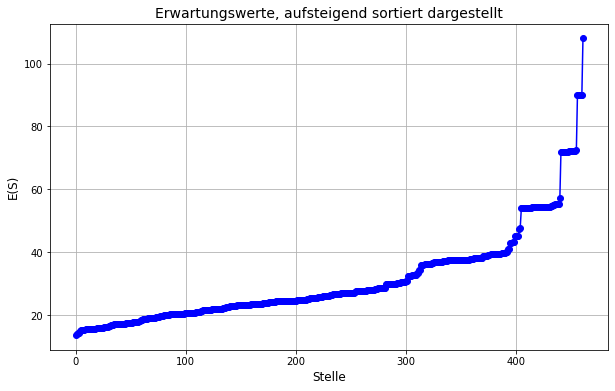

In [29]:
import numpy as np
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt

# Eingabe von p, Anzahl an Chips, Anzahl an Feldern, Anzahl der Ausgabewerte
p = [3/18, 5/18, 4/18, 3/18, 2/18, 1/18]  # Wahrscheinlichkeiten
Chips = 6
Felder = 6
n = 20

# Memoization dictionary für bereits berechnete Zustände
memo = {}

# Rekursive Funktion für den Erwartungswert mit beliebigen m Feldern
def expected_value(chips, probs):
    # Basisfall: Wenn keine Chips mehr übrig sind, ist der erwartete Wert 0
    if all(c == 0 for c in chips):
        return 0
    
    # Umwandeln der chips-Liste in ein Tupel, um es als Schlüssel im Memo zu verwenden
    chips_tuple = tuple(chips)
    
    # Wenn der Zustand bereits berechnet wurde, aus dem Cache holen
    if chips_tuple in memo:
        return memo[chips_tuple]
    
    # Berechnung des Erwartungswerts für den aktuellen Zustand
    weighted_sum = 0  # Gewichtete Summe der rekursiven Aufrufe
    total_weight = 0  # Summe der Wahrscheinlichkeiten der möglichen Züge
    
    # Durch alle Felder iterieren
    for i in range(len(chips)):
        if chips[i] > 0:  # Nur Felder mit Chips berücksichtigen
            # Verringere die Anzahl der Chips auf dem aktuellen Feld um 1
            new_chips = chips[:]
            new_chips[i] -= 1
            # Rekursiver Aufruf
            weighted_sum += probs[i] * expected_value(new_chips, probs)
            total_weight += probs[i]
    
    # Normiere sowohl die 1 als auch die gewichtete Summe durch total_weight
    if total_weight > 0:
        result = (1 / total_weight) + (weighted_sum / total_weight)
    else:
        result = 0  # Sicherheitscheck, sollte aber nie passieren
    
    # Speichern des Ergebnisses in der Memoization-Tabelle
    memo[chips_tuple] = result
    return result

# Generiere alle möglichen Strategien für 18 Chips auf 6 Feldern
def generate_states(total_chips, num_fields):
    """
    Erzeugt alle möglichen Verteilungen von 'total_chips' auf 'num_fields' Felder.
    """
    for c in combinations_with_replacement(range(num_fields), total_chips):
        strategy = [0] * num_fields
        for i in c:
            strategy[i] += 1
        yield strategy

# Berechne Erwartungswerte für alle Zustände und speichere sie in einer Liste
def calculate_expected_values(states, probs):
    results = []
    for state in states:
        ev = expected_value(state, probs)
        results.append((state, ev))
    return results

# Zeichne einen Graphen der Erwartungswerte
def plot_values(data):
    states = [str(state) for state, _ in data]
    evs = [ev for _, ev in data]
    
    plt.figure(figsize=(10,6))
    plt.plot(range(len(evs)), evs, marker='o', linestyle='-', color='b')
    plt.title("Erwartungswerte, aufsteigend sortiert dargestellt",fontsize=14)
    plt.xlabel("Stelle",fontsize=12)
    plt.ylabel("E(S)",fontsize=12)
    plt.grid(True)
    plt.show()
    

#
# Alle möglichen Verteilungen
states = generate_states(Chips, Felder)
    
# Berechne die Erwartungswerte für alle Verteilungen
results = calculate_expected_values(states, p)
    
# Sortiere nach Erwartungswert
sorted_results = sorted(results, key=lambda x: x[1])
 
Anzahl_Werte=len(sorted_results)  
print(f"Anzahl der generierten Strategien: {Anzahl_Werte}")

if  n>Anzahl_Werte: n=Anzahl_Werte
for i in range(n):
    print(i+1,sorted_results[i])

# Zeichne einen Graphen der Erwartungswerte
plot_values(sorted_results)